# U-Net – Oxford-IIIT Pet Image Segmentation

This project implements a U-Net from scratch for semantic image segmentation using the Oxford-IIIT Pet dataset. The model receives a pet image and predicts a pixel-level segmentation mask with three classes representing foreground, background, and boundary regions. The notebook covers dataset preparation, synchronized image-mask preprocessing, U-Net construction, mixed-precision training, segmentation metrics, model evaluation, and qualitative prediction analysis.


## 1. Project Overview

The project focuses on pixel-level semantic segmentation with a U-Net encoder-decoder architecture.


In [1]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode
from torchvision.datasets import OxfordIIITPet

from IPython.display import display

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)


PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128


## 2. Import Required Libraries

The notebook uses PyTorch and Torchvision for model development, data loading, training, and visualization.


In [2]:
SEED = 42
IMAGE_SIZE = 128
BATCH_SIZE = 16
NUM_CLASSES = 3
NUM_EPOCHS = 15
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 2
GRAD_CLIP_NORM = 1.0

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"

print("Device:", DEVICE)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
print("Mixed precision:", USE_AMP)


Device: cuda
GPU: Tesla T4
Mixed precision: True


## 3. Configure Reproducibility and Runtime

The training configuration is fixed for reproducible experiments and is designed for Google Colab with an NVIDIA Tesla T4.


In [3]:
DATA_ROOT = Path("./oxford_iiit_pet")
MODEL_PATH = Path("./best_unet_oxford_pet.pt")

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
CLASS_NAMES = ["Foreground", "Background", "Border"]

print("Dataset path:", DATA_ROOT.resolve())
print("Image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)
print("Epochs:", NUM_EPOCHS)


Dataset path: /content/oxford_iiit_pet
Image size: 128
Batch size: 16
Epochs: 15


## 4. Define Dataset Paths and Configuration

The dataset and model checkpoint paths are defined once so the notebook can be rerun without changing the training pipeline.


In [4]:
trainval_base = OxfordIIITPet(
    root=DATA_ROOT,
    split="trainval",
    target_types="segmentation",
    download=True
)

test_base = OxfordIIITPet(
    root=DATA_ROOT,
    split="test",
    target_types="segmentation",
    download=True
)

print("Train/validation samples:", len(trainval_base))
print("Test samples:", len(test_base))


100%|██████████| 792M/792M [00:40<00:00, 19.7MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 9.87MB/s]


Train/validation samples: 3680
Test samples: 3669


## 5. Load Oxford-IIIT Pet Segmentation Data

The Oxford-IIIT Pet dataset provides pet images together with pixel-level trimap segmentation masks.


In [5]:
trainval_size = len(trainval_base)
train_size = int(0.8 * trainval_size)
val_size = trainval_size - train_size

split_generator = torch.Generator().manual_seed(SEED)
train_indices, val_indices = torch.utils.data.random_split(
    range(trainval_size),
    [train_size, val_size],
    generator=split_generator
)

train_indices = train_indices.indices
val_indices = val_indices.indices

print("Training samples:", len(train_indices))
print("Validation samples:", len(val_indices))
print("Test samples:", len(test_base))


Training samples: 2944
Validation samples: 736
Test samples: 3669


## 6. Create Train, Validation, and Test Splits

The trainval portion is split deterministically into training and validation sets while the official test split remains untouched.


In [6]:
class PetSegmentationDataset(Dataset):
    def __init__(self, base_dataset, indices, image_size, train=False):
        self.base_dataset = base_dataset
        self.indices = list(indices)
        self.image_size = image_size
        self.train = train

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, index):
        image, mask = self.base_dataset[self.indices[index]]

        if self.train and random.random() < 0.5:
            image = TF.hflip(image)
            mask = TF.hflip(mask)

        image = TF.resize(
            image,
            [self.image_size, self.image_size],
            interpolation=InterpolationMode.BILINEAR
        )
        mask = TF.resize(
            mask,
            [self.image_size, self.image_size],
            interpolation=InterpolationMode.NEAREST
        )

        image = TF.to_tensor(image)
        image = TF.normalize(
            image,
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )

        mask = torch.as_tensor(
            np.asarray(mask, dtype=np.int64),
            dtype=torch.long
        ) - 1

        return image, mask

train_dataset = PetSegmentationDataset(
    trainval_base, train_indices, IMAGE_SIZE, train=True
)
val_dataset = PetSegmentationDataset(
    trainval_base, val_indices, IMAGE_SIZE, train=False
)
test_dataset = PetSegmentationDataset(
    test_base, range(len(test_base)), IMAGE_SIZE, train=False
)

print("Dataset objects created.")
print("Sample image shape:", train_dataset[0][0].shape)
print("Sample mask shape:", train_dataset[0][1].shape)
print("Mask classes:", torch.unique(train_dataset[0][1]).tolist())


Dataset objects created.
Sample image shape: torch.Size([3, 128, 128])
Sample mask shape: torch.Size([128, 128])
Mask classes: [0, 1, 2]


## 7. Build the Segmentation Dataset Pipeline

Images and masks use synchronized resizing, optional horizontal flipping for training, and tensor normalization while preserving discrete mask labels.


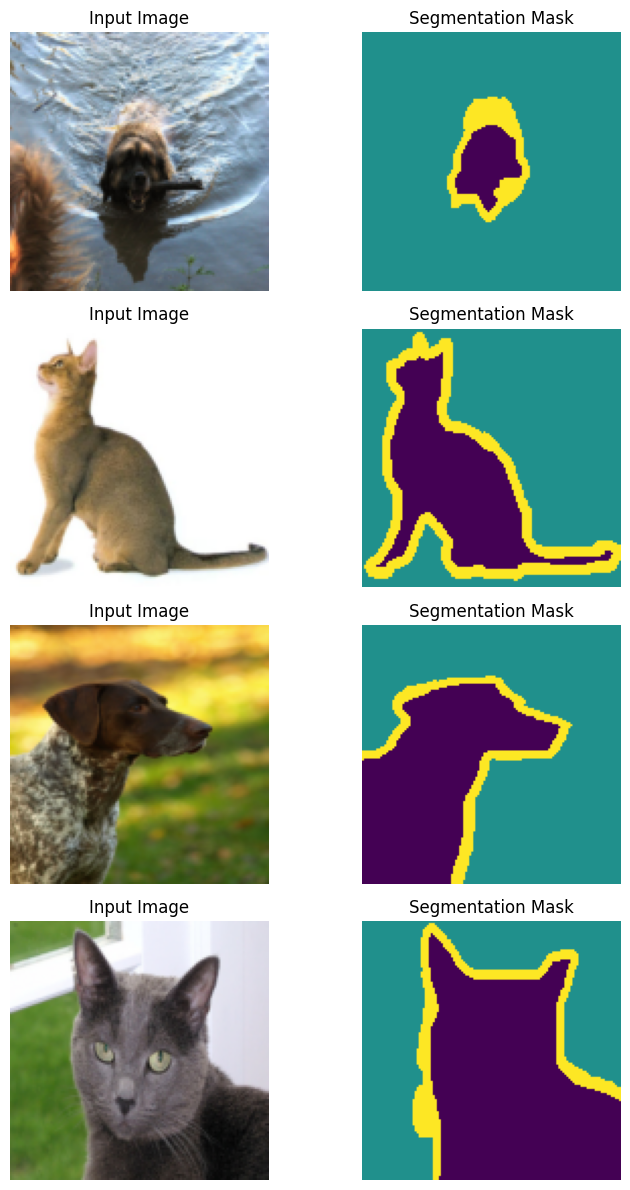

In [7]:
sample_indices = [0, 1, 2, 3]
fig, axes = plt.subplots(len(sample_indices), 2, figsize=(8, 12))

for row, index in enumerate(sample_indices):
    image, mask = train_dataset[index]
    image_display = (
        image.cpu() * IMAGENET_STD + IMAGENET_MEAN
    ).clamp(0, 1).permute(1, 2, 0).numpy()

    axes[row, 0].imshow(image_display)
    axes[row, 0].set_title("Input Image")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(mask.numpy())
    axes[row, 1].set_title("Segmentation Mask")
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()


## 8. Inspect Sample Images and Masks

Sample pairs are displayed to verify that the image and segmentation mask remain spatially aligned after preprocessing.


In [8]:
def update_confusion_matrix(confusion_matrix, predictions, targets, num_classes):
    predictions = predictions.reshape(-1)
    targets = targets.reshape(-1)
    valid = (targets >= 0) & (targets < num_classes)

    encoded = num_classes * targets[valid] + predictions[valid]
    counts = torch.bincount(
        encoded,
        minlength=num_classes * num_classes
    )

    confusion_matrix += counts.reshape(num_classes, num_classes)
    return confusion_matrix


def segmentation_metrics(confusion_matrix):
    diagonal = torch.diag(confusion_matrix).float()
    row_sum = confusion_matrix.sum(dim=1).float()
    column_sum = confusion_matrix.sum(dim=0).float()

    denominator = row_sum + column_sum - diagonal
    iou = diagonal / denominator.clamp_min(1.0)

    pixel_accuracy = diagonal.sum() / confusion_matrix.sum().clamp_min(1.0)
    mean_iou = iou.mean()

    return pixel_accuracy.item(), mean_iou.item(), iou.cpu().numpy()

print("Metric functions ready.")


Metric functions ready.


## 9. Define Segmentation Metrics

The evaluation pipeline tracks pixel accuracy, mean intersection-over-union, and IoU for each segmentation class.


In [9]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.block(x)


class Up(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(
            in_channels,
            in_channels // 2,
            kernel_size=2,
            stride=2
        )
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        diff_y = x2.size(2) - x1.size(2)
        diff_x = x2.size(3) - x1.size(3)

        x1 = F.pad(
            x1,
            [
                diff_x // 2,
                diff_x - diff_x // 2,
                diff_y // 2,
                diff_y - diff_y // 2
            ]
        )

        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.inc = DoubleConv(3, 32)
        self.down1 = Down(32, 64)
        self.down2 = Down(64, 128)
        self.down3 = Down(128, 256)
        self.down4 = Down(256, 512)
        self.up1 = Up(512, 256)
        self.up2 = Up(256, 128)
        self.up3 = Up(128, 64)
        self.up4 = Up(64, 32)
        self.outc = OutConv(32, num_classes)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        return self.outc(x)


model = UNet(NUM_CLASSES).to(DEVICE)
print(model)


UNet(
  (inc): DoubleConv(
    (block): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down1): Down(
    (block): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): DoubleConv(
        (block): Sequential(
          (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (4): BatchNorm

## 10. Build the U-Net

The U-Net uses a convolutional encoder, bottleneck, decoder, and skip connections to recover fine spatial information.


In [10]:
total_params = sum(parameter.numel() for parameter in model.parameters())
trainable_params = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

parameter_table = pd.DataFrame({
    "Parameter": ["Total", "Trainable"],
    "Count": [total_params, trainable_params]
})

display(parameter_table)


,Parameter,Count
0,Total,7763107
1,Trainable,7763107


## 11. Inspect the Network Parameters

The parameter count provides a quick view of the model size and trainable capacity.


In [11]:
loader_kwargs = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": DEVICE.type == "cuda"
}

train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    drop_last=False,
    **loader_kwargs
)

val_loader = DataLoader(
    val_dataset,
    shuffle=False,
    drop_last=False,
    **loader_kwargs
)

test_loader = DataLoader(
    test_dataset,
    shuffle=False,
    drop_last=False,
    **loader_kwargs
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))


Training batches: 184
Validation batches: 46
Test batches: 230


## 12. Create DataLoaders

The DataLoaders batch the segmentation data and enable efficient training and evaluation on the selected device.


In [12]:
def multiclass_dice_loss(logits, targets, smooth=1.0):
    probabilities = torch.softmax(logits, dim=1)
    one_hot_targets = F.one_hot(
        targets,
        num_classes=NUM_CLASSES
    ).permute(0, 3, 1, 2).float()

    dimensions = (0, 2, 3)
    intersection = (probabilities * one_hot_targets).sum(dimensions)
    denominator = probabilities.sum(dimensions) + one_hot_targets.sum(dimensions)
    dice = (2.0 * intersection + smooth) / (denominator + smooth)

    return 1.0 - dice.mean()


class CombinedSegmentationLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.cross_entropy = nn.CrossEntropyLoss()

    def forward(self, logits, targets):
        ce_loss = self.cross_entropy(logits, targets)
        dice_loss = multiclass_dice_loss(logits, targets)
        return ce_loss + dice_loss


criterion = CombinedSegmentationLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=USE_AMP
)

print("Loss:", criterion)
print("Optimizer:", optimizer.__class__.__name__)
print("Scheduler:", scheduler.__class__.__name__)


Loss: CombinedSegmentationLoss(
  (cross_entropy): CrossEntropyLoss()
)
Optimizer: AdamW
Scheduler: CosineAnnealingLR


## 13. Configure Loss, Optimizer, and Scheduler

Training combines cross-entropy and multiclass Dice loss to balance class prediction with region overlap.


In [13]:
def train_one_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    running_loss = 0.0
    sample_count = 0
    confusion_matrix = torch.zeros(
        NUM_CLASSES, NUM_CLASSES, dtype=torch.long, device=DEVICE
    )

    for images, masks in loader:
        images = images.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(
            device_type=DEVICE.type, dtype=torch.float16, enabled=USE_AMP
        ):
            logits = model(images)
            loss = criterion(logits, masks)

        if USE_AMP:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            optimizer.step()

        predictions = logits.argmax(dim=1)
        update_confusion_matrix(
            confusion_matrix, predictions.detach(), masks.detach(), NUM_CLASSES
        )

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        sample_count += batch_size

    pixel_accuracy, mean_iou, class_iou = segmentation_metrics(confusion_matrix)
    return running_loss / sample_count, pixel_accuracy, mean_iou, class_iou


@torch.no_grad()
def evaluate_one_epoch(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    sample_count = 0
    confusion_matrix = torch.zeros(
        NUM_CLASSES, NUM_CLASSES, dtype=torch.long, device=DEVICE
    )

    for images, masks in loader:
        images = images.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)

        with torch.autocast(
            device_type=DEVICE.type, dtype=torch.float16, enabled=USE_AMP
        ):
            logits = model(images)
            loss = criterion(logits, masks)

        predictions = logits.argmax(dim=1)
        update_confusion_matrix(
            confusion_matrix, predictions, masks, NUM_CLASSES
        )

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        sample_count += batch_size

    pixel_accuracy, mean_iou, class_iou = segmentation_metrics(confusion_matrix)
    return running_loss / sample_count, pixel_accuracy, mean_iou, class_iou


print("Training and evaluation functions ready.")


Training and evaluation functions ready.


## 14. Define Training and Validation Functions

The training loop records loss, pixel accuracy, mean IoU, and per-class IoU for every epoch.


In [14]:
history = []
best_val_iou = -np.inf
best_epoch = 0

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc, train_iou, train_class_iou = train_one_epoch(
        model, train_loader, criterion, optimizer, scaler
    )

    val_loss, val_acc, val_iou, val_class_iou = evaluate_one_epoch(
        model, val_loader, criterion
    )

    scheduler.step()

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_pixel_accuracy": train_acc,
        "train_mean_iou": train_iou,
        "val_loss": val_loss,
        "val_pixel_accuracy": val_acc,
        "val_mean_iou": val_iou,
        "learning_rate": optimizer.param_groups[0]["lr"]
    })

    if val_iou > best_val_iou:
        best_val_iou = val_iou
        best_epoch = epoch
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "epoch": epoch,
                "val_mean_iou": val_iou
            },
            MODEL_PATH
        )

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"Train Loss {train_loss:.4f} | "
        f"Train mIoU {train_iou:.4f} | "
        f"Val Loss {val_loss:.4f} | "
        f"Val mIoU {val_iou:.4f} | "
        f"Val Acc {val_acc:.4f}"
    )

print("Training complete.")
print("Best validation mIoU:", round(best_val_iou, 4))
print("Best epoch:", best_epoch)
print("Checkpoint:", MODEL_PATH.resolve())


Epoch 01/15 | Train Loss 1.1036 | Train mIoU 0.4861 | Val Loss 1.1962 | Val mIoU 0.4810 | Val Acc 0.7155
Epoch 02/15 | Train Loss 0.8667 | Train mIoU 0.5761 | Val Loss 0.8753 | Val mIoU 0.5886 | Val Acc 0.8098
Epoch 03/15 | Train Loss 0.7483 | Train mIoU 0.6222 | Val Loss 0.7164 | Val mIoU 0.6336 | Val Acc 0.8388
Epoch 04/15 | Train Loss 0.6896 | Train mIoU 0.6462 | Val Loss 0.6648 | Val mIoU 0.6529 | Val Acc 0.8532
Epoch 05/15 | Train Loss 0.6450 | Train mIoU 0.6644 | Val Loss 0.6013 | Val mIoU 0.6802 | Val Acc 0.8686
Epoch 06/15 | Train Loss 0.6035 | Train mIoU 0.6805 | Val Loss 0.5944 | Val mIoU 0.6881 | Val Acc 0.8755
Epoch 07/15 | Train Loss 0.5765 | Train mIoU 0.6920 | Val Loss 0.5387 | Val mIoU 0.7083 | Val Acc 0.8845
Epoch 08/15 | Train Loss 0.5437 | Train mIoU 0.7058 | Val Loss 0.5525 | Val mIoU 0.7030 | Val Acc 0.8802
Epoch 09/15 | Train Loss 0.5131 | Train mIoU 0.7182 | Val Loss 0.5382 | Val mIoU 0.7116 | Val Acc 0.8859
Epoch 10/15 | Train Loss 0.4938 | Train mIoU 0.7279 | V

## 15. Train the U-Net

The model is trained for the configured number of epochs and the checkpoint with the highest validation mean IoU is retained.


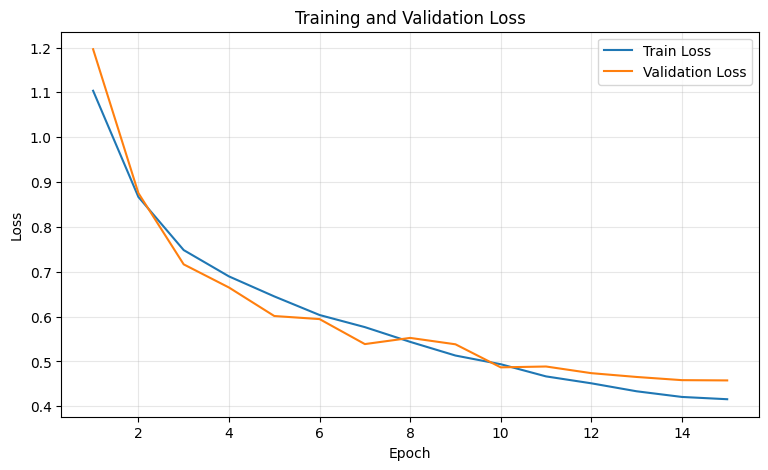

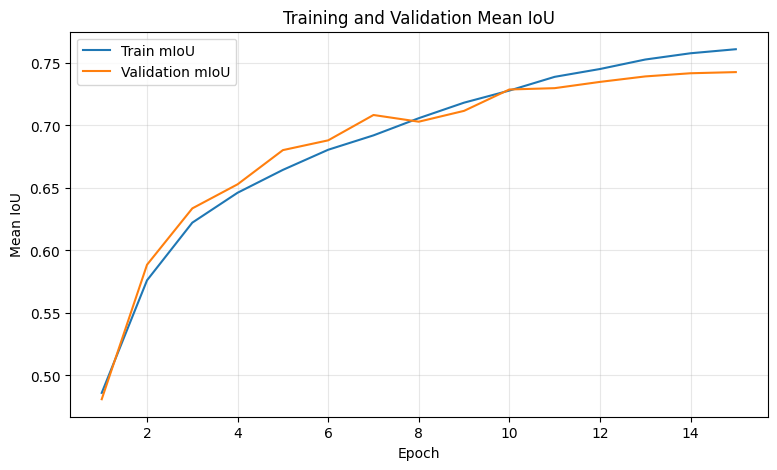

In [15]:
history_df = pd.DataFrame(history)

plt.figure(figsize=(9, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(history_df["epoch"], history_df["train_mean_iou"], label="Train mIoU")
plt.plot(history_df["epoch"], history_df["val_mean_iou"], label="Validation mIoU")
plt.xlabel("Epoch")
plt.ylabel("Mean IoU")
plt.title("Training and Validation Mean IoU")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 16. Plot Training History

The learning curves show how segmentation loss and mean IoU change across training epochs.


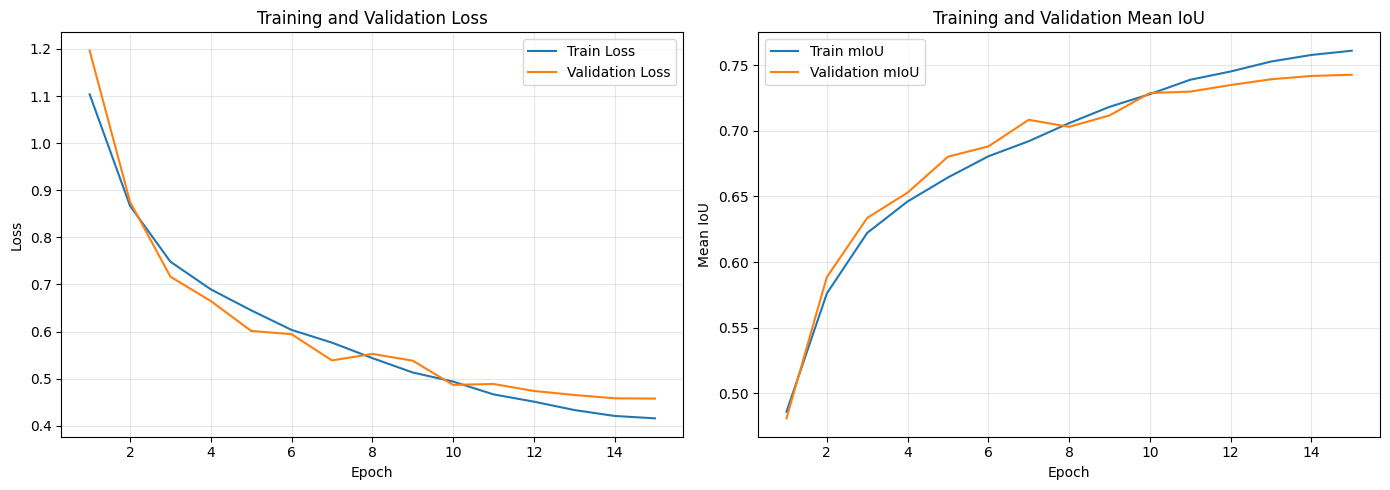

In [16]:
history_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Train Loss"
)
axes[0].plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation Loss"
)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training and Validation Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    history_df["epoch"],
    history_df["train_mean_iou"],
    label="Train mIoU"
)
axes[1].plot(
    history_df["epoch"],
    history_df["val_mean_iou"],
    label="Validation mIoU"
)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Mean IoU")
axes[1].set_title("Training and Validation Mean IoU")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 17. Evaluate the Trained Model

The best validation checkpoint is evaluated on the official test split using loss, pixel accuracy, and mean IoU.


In [17]:
checkpoint = torch.load(
    MODEL_PATH,
    map_location=DEVICE,
    weights_only=False
)

model.load_state_dict(checkpoint["model_state_dict"])

test_loss, test_pixel_accuracy, test_mean_iou, test_class_iou = evaluate_one_epoch(
    model, test_loader, criterion
)

print("Best epoch:", checkpoint["epoch"])
print(f"Test loss: {test_loss:.4f}")
print(f"Test pixel accuracy: {test_pixel_accuracy:.4f}")
print(f"Test mean IoU: {test_mean_iou:.4f}")


Best epoch: 15
Test loss: 0.4639
Test pixel accuracy: 0.9027
Test mean IoU: 0.7463


## 18. Inspect Per-Class IoU

Per-class intersection-over-union highlights which segmentation labels are easier or harder for the model to predict.


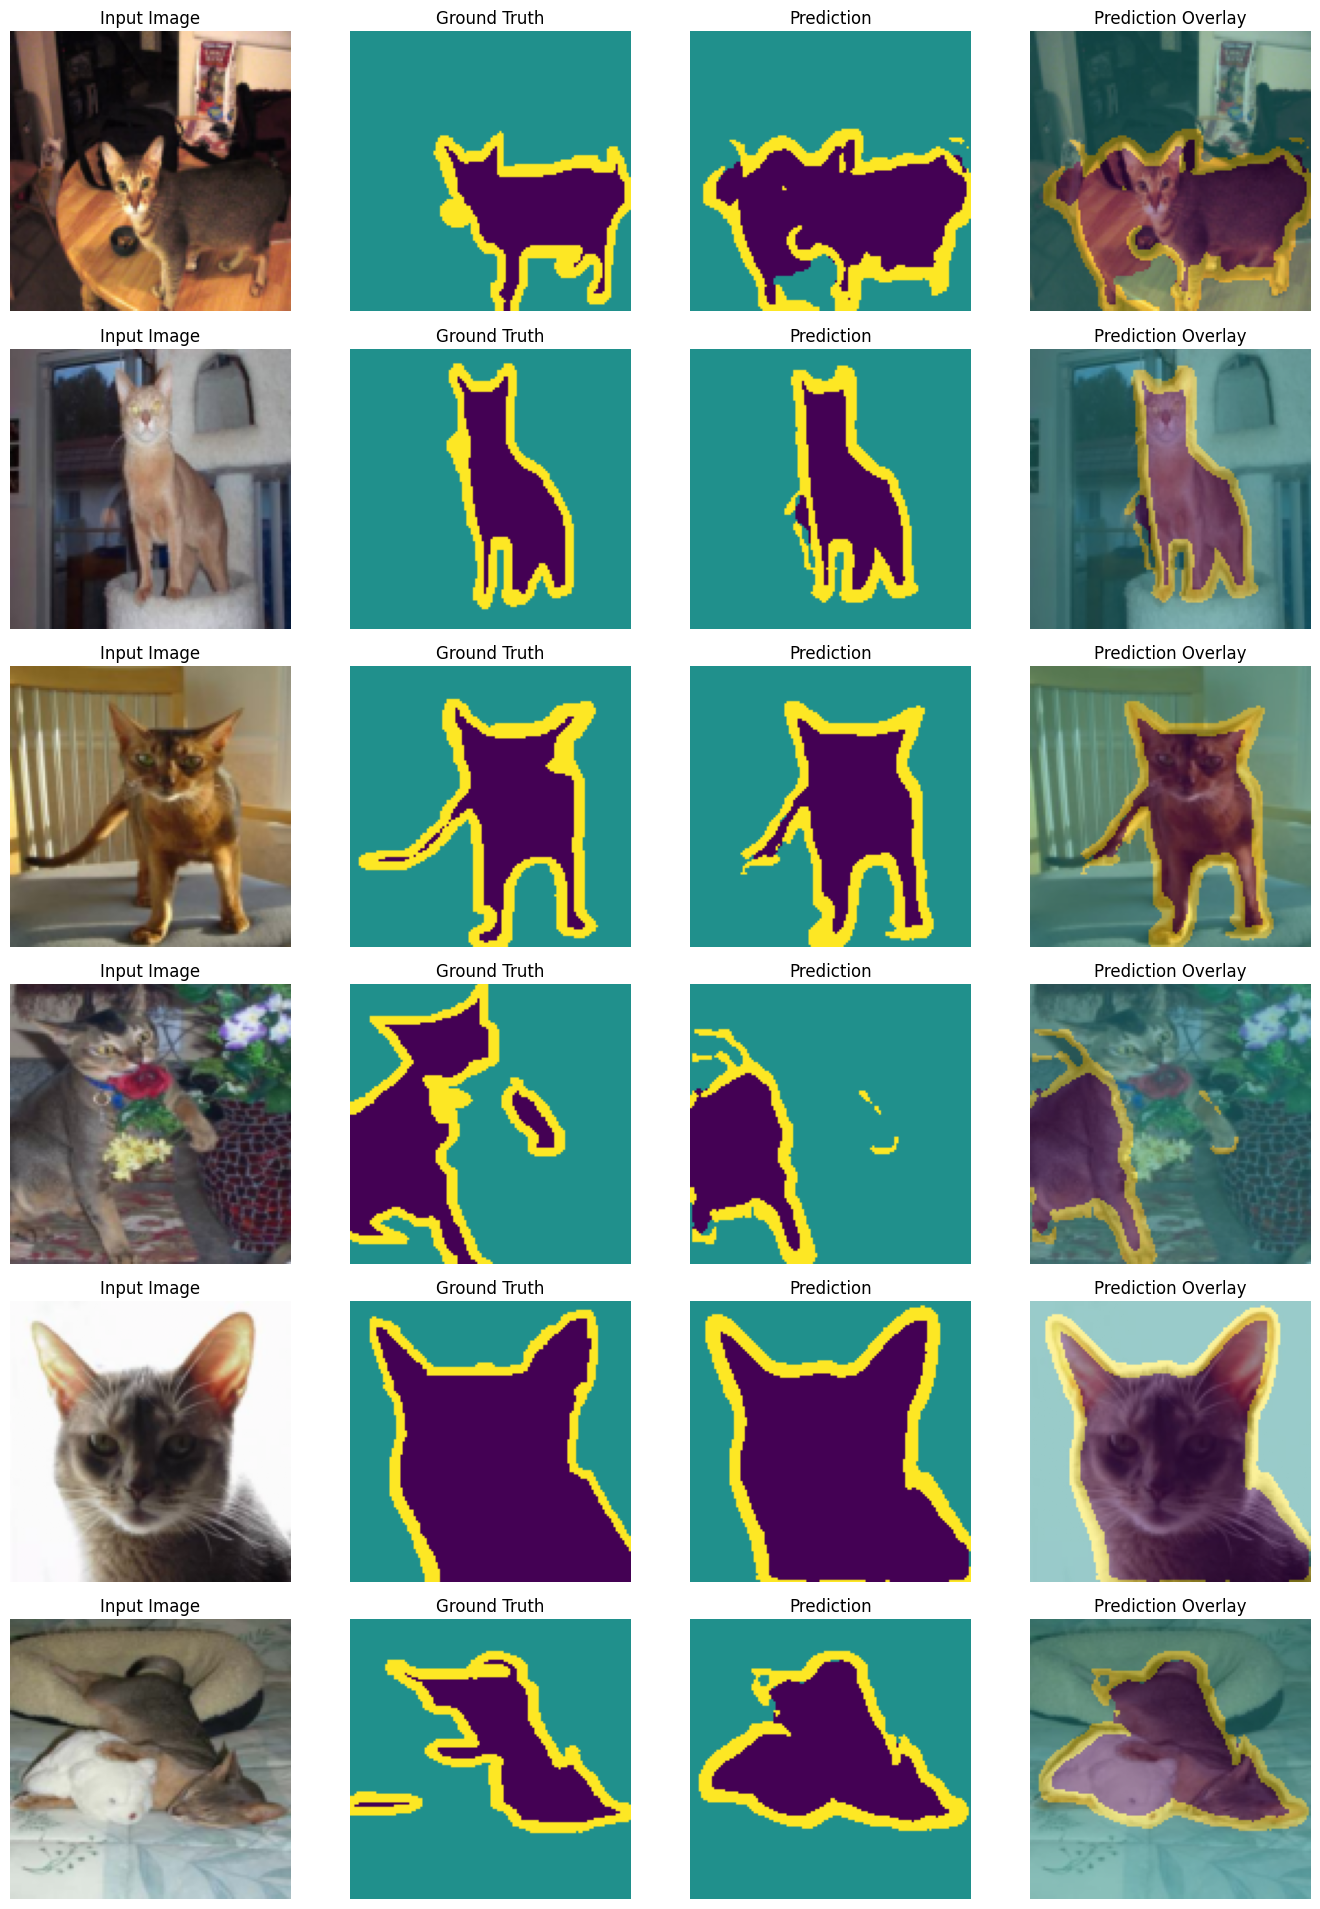

In [18]:
@torch.no_grad()
def get_predictions(model, dataset, indices):
    model.eval()
    outputs = []

    for index in indices:
        image, mask = dataset[index]
        logits = model(image.unsqueeze(0).to(DEVICE))
        prediction = logits.argmax(dim=1).squeeze(0).cpu()

        image_display = (
            image.cpu() * IMAGENET_STD + IMAGENET_MEAN
        ).clamp(0, 1).permute(1, 2, 0)

        outputs.append((image_display, mask.cpu(), prediction))

    return outputs


display_indices = [0, 1, 2, 3, 4, 5]
prediction_samples = get_predictions(model, test_dataset, display_indices)

fig, axes = plt.subplots(
    len(prediction_samples), 4,
    figsize=(14, 3.2 * len(prediction_samples))
)

for row, (image, true_mask, prediction) in enumerate(prediction_samples):
    axes[row, 0].imshow(image)
    axes[row, 0].set_title("Input Image")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(true_mask)
    axes[row, 1].set_title("Ground Truth")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(prediction)
    axes[row, 2].set_title("Prediction")
    axes[row, 2].axis("off")

    axes[row, 3].imshow(image)
    axes[row, 3].imshow(prediction, alpha=0.45)
    axes[row, 3].set_title("Prediction Overlay")
    axes[row, 3].axis("off")

plt.tight_layout()
plt.show()


## 19. Visualize Segmentation Predictions

Predicted masks are compared with ground truth masks to assess the quality of the learned pixel-level boundaries.


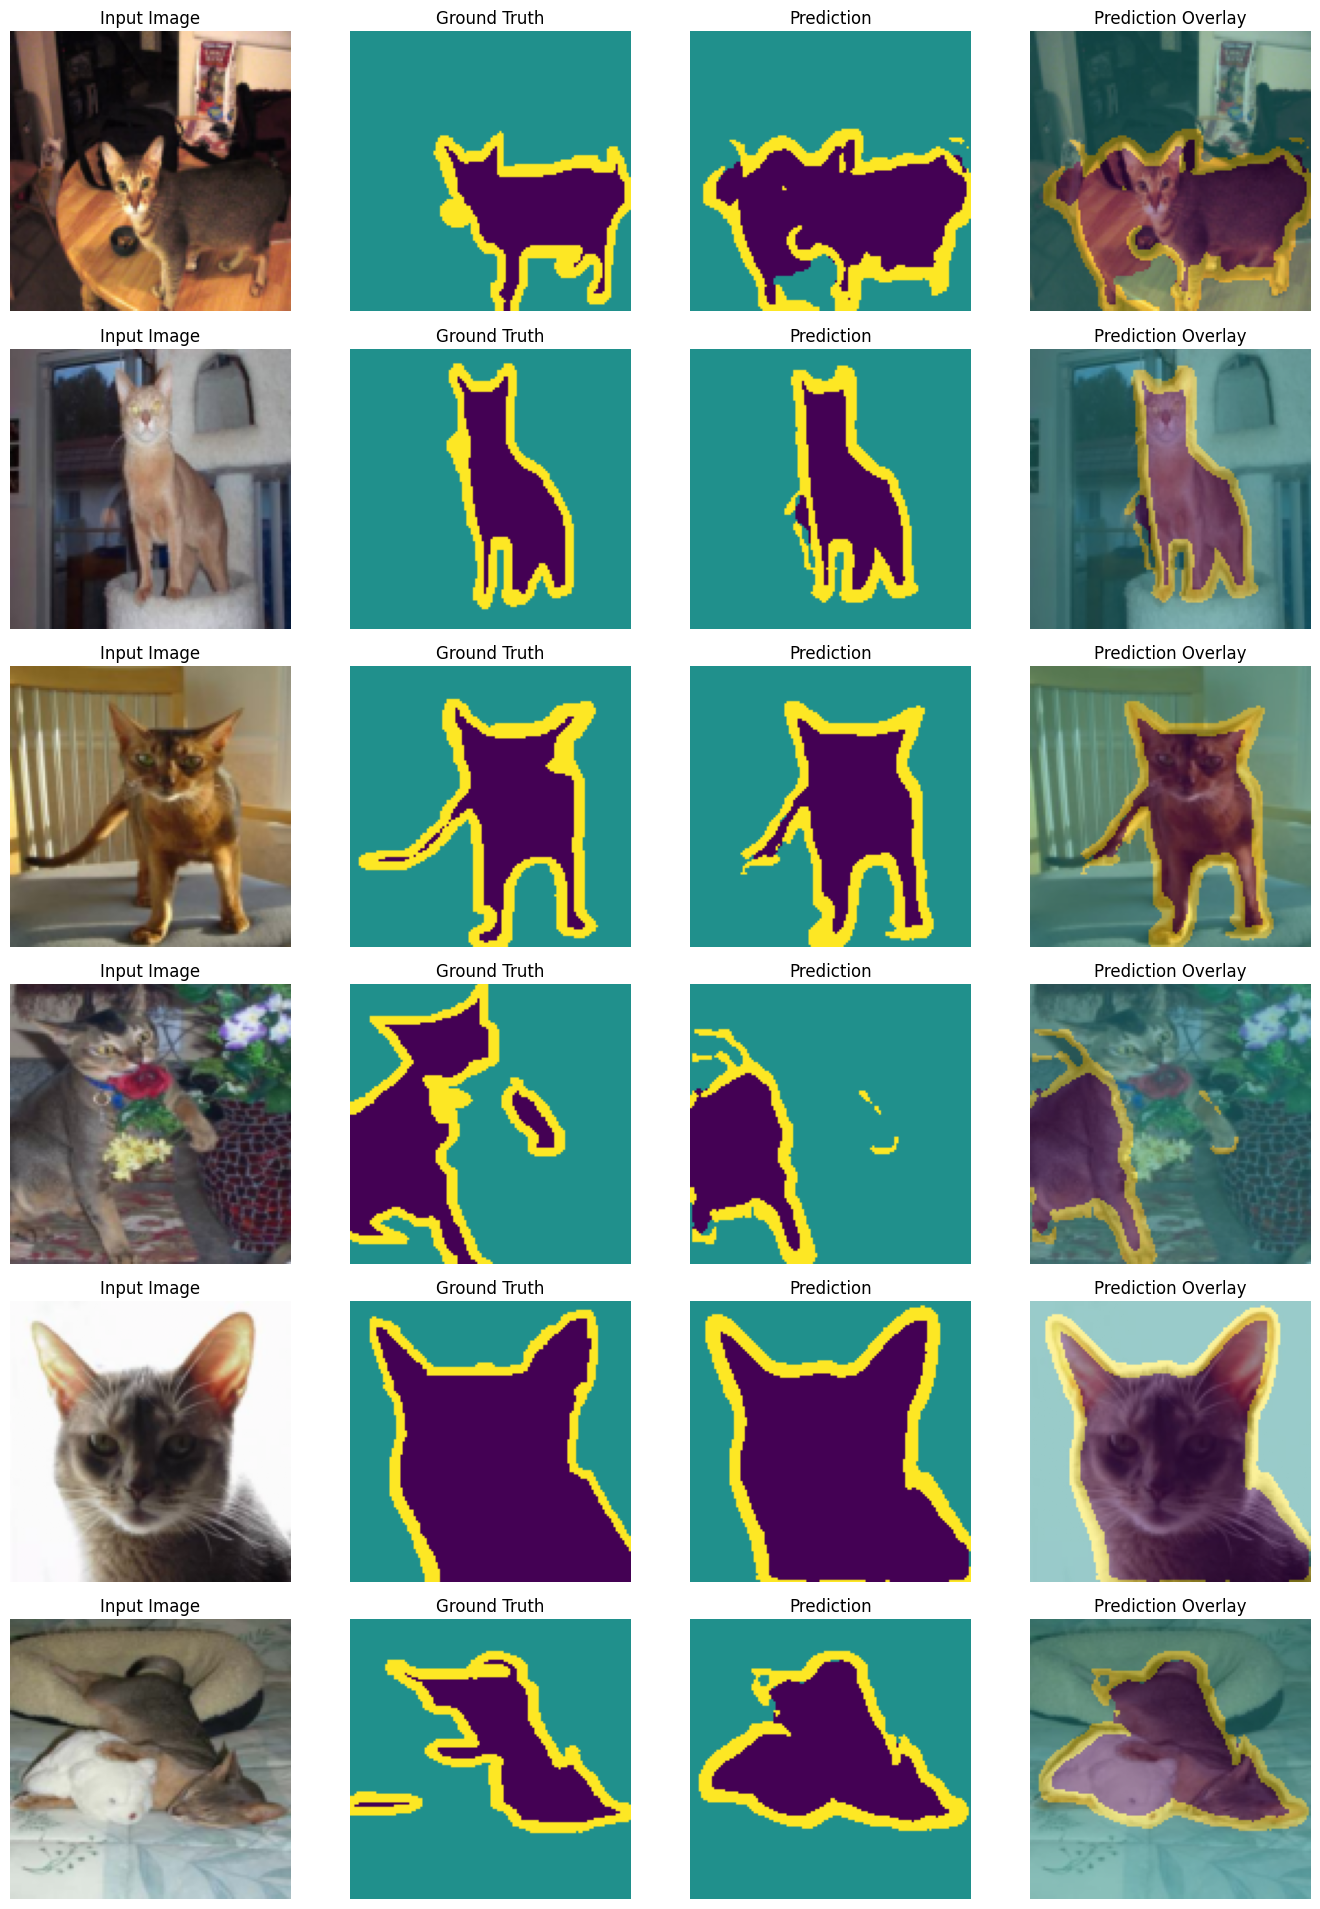

In [19]:
@torch.no_grad()
def get_predictions(model, dataset, indices):
    model.eval()
    outputs = []

    for index in indices:
        image, mask = dataset[index]
        logits = model(image.unsqueeze(0).to(DEVICE))
        prediction = logits.argmax(dim=1).squeeze(0).cpu()

        image_display = (
            image.cpu() * IMAGENET_STD + IMAGENET_MEAN
        ).clamp(0, 1).permute(1, 2, 0)

        outputs.append((image_display, mask.cpu(), prediction))

    return outputs


display_indices = [0, 1, 2, 3, 4, 5]
prediction_samples = get_predictions(model, test_dataset, display_indices)

fig, axes = plt.subplots(
    len(prediction_samples), 4,
    figsize=(14, 3.2 * len(prediction_samples))
)

for row, (image, true_mask, prediction) in enumerate(prediction_samples):
    axes[row, 0].imshow(image)
    axes[row, 0].set_title("Input Image")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(true_mask)
    axes[row, 1].set_title("Ground Truth")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(prediction)
    axes[row, 2].set_title("Prediction")
    axes[row, 2].axis("off")

    axes[row, 3].imshow(image)
    axes[row, 3].imshow(prediction, alpha=0.45)
    axes[row, 3].set_title("Prediction Overlay")
    axes[row, 3].axis("off")

plt.tight_layout()
plt.show()


,Class,IoU
0,Foreground,0.817806
1,Background,0.901856
2,Border,0.519215


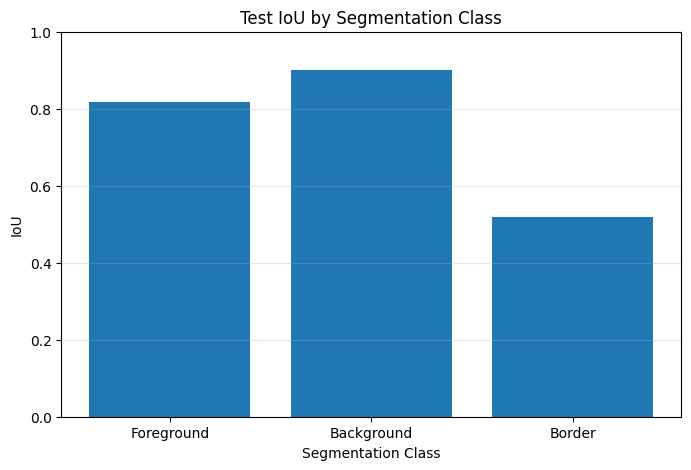

In [20]:
results_df = pd.DataFrame({
    "Class": CLASS_NAMES,
    "IoU": test_class_iou
})

display(results_df)

plt.figure(figsize=(8, 5))
plt.bar(results_df["Class"], results_df["IoU"])
plt.ylim(0, 1)
plt.xlabel("Segmentation Class")
plt.ylabel("IoU")
plt.title("Test IoU by Segmentation Class")
plt.grid(axis="y", alpha=0.3)
plt.show()


## 20. Key Findings



## 21. Conclusion

